<a href="https://colab.research.google.com/github/chasemaneuver/Analisi-1/blob/main/capitolo_1_numeri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi 1 · Numeri

## Un laboratorio sul capitolo 1 di Bramanti, Pagani e Salsa

**Fonte:** *Analisi matematica 1*, Zanichelli, ISBN 978-88-08-06485-1, capitolo 1, pagine **1–47**.

Questo quaderno rielabora il capitolo in forma didattica: include le definizioni, gli enunciati, le proposizioni, le proprietà, gli esempi matematici e le soluzioni dei **35 esercizi e 7 complementi**. Gli enunciati sono riscritti e gli svolgimenti sono sviluppati per questo quaderno. I laboratori e le domande di esplorazione sono aggiunte didattiche. Le dimostrazioni che richiedono risultati successivi sono esplicitamente segnalate.

**Come studiare:** leggi un enunciato, prova l'esempio su carta, poi, prima di muovere un cursore, fai una previsione.

**Convenzioni:** $\mathbb N=\{0,1,2,\ldots\}$; $\mathbb N_{>0}=\{1,2,\ldots\}$; $\subseteq$ ammette l'uguaglianza, $\subsetneq$ indica inclusione propria. Gli argomenti principali complessi sono in $(-\pi,\pi]$. Per le radici complesse useremo insiemi di soluzioni, evitando di confonderle con la radice aritmetica positiva.

### Percorso

1. Insiemi e logica (§1, pp. 1–13)
2. Sommatorie, fattoriali e binomio (§2, pp. 13–18; esercizi 1–7)
3. Campi ordinati (§3, pp. 18–20)
4. Reali, estremi, valore assoluto e intervalli (§4, pp. 20–25)
5. Radicali, potenze, logaritmi e approssimazioni (§5, pp. 25–28)
6. Insiemi infiniti (§6, pp. 28–32)
7. Induzione (§7, pp. 32–35; esercizi 8–13)
8. Numeri complessi (§8, pp. 35–47; esercizi 14–35)
9. Complementi 1–7 (p. 47)
10. Autoverifica e controlli computazionali

In [1]:
import importlib.util
import subprocess
import sys

richieste = {'numpy': 'numpy', 'matplotlib': 'matplotlib',
             'sympy': 'sympy', 'ipywidgets': 'ipywidgets'}
mancanti = [pkg for mod, pkg in richieste.items()
            if importlib.util.find_spec(mod) is None]
if mancanti:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *mancanti])

import math
from fractions import Fraction
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import ipywidgets as widgets
from IPython.display import display, Markdown

plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .2})
BLU, ARANCIO, VERDE = '#195c91', '#c46018', '#25816b'

def laboratorio(funzione, **controlli):
    """Grafico iniziale esportabile + controlli per l'esplorazione dal vivo."""
    funzione(**{nome: controllo.value for nome, controllo in controlli.items()})
    interazione = widgets.interactive(funzione, **controlli)
    display(interazione)
    return interazione

print('Laboratori pronti. I calcoli simbolici usano valori esatti; i grafici approssimazioni.')

Laboratori pronti. I calcoli simbolici usano valori esatti; i grafici approssimazioni.


## 1. Insiemi e logica

### 1.1 Il vocabolario degli insiemi

**Insieme, elemento, appartenenza** sono nozioni primitive. Scriviamo $x\in A$ se $x$ è un elemento di $A$, $x\notin A$ altrimenti. Si può specificare un insieme elencandone gli elementi oppure mediante una proprietà: $\{x\in X:p(x)\}$. Ordine e ripetizioni nell'elenco non contano: $\{1,2,5\}=\{5,1,2,1\}$.

**Uguaglianza e inclusione.** $A=B$ significa che i due insiemi hanno esattamente gli stessi elementi. $A\subseteq B$ significa $\forall x\,(x\in A\Rightarrow x\in B)$. Quindi $A=B$ se e solo se $A\subseteq B$ e $B\subseteq A$. L'inclusione propria richiede inoltre $A\ne B$.

**Insieme vuoto e insieme delle parti.** $\varnothing$ non ha elementi; è sottoinsieme di ogni insieme. $\mathcal P(A)=\{B:B\subseteq A\}$. Ad esempio $\mathcal P(\{1,2\})=\{\varnothing,\{1\},\{2\},\{1,2\}\}$. Non confondere $0$, $\varnothing$ e $\{0\}$.

Per l'esempio del libro $X=\{1,2,3\}$, le otto parti sono $\varnothing$, $\{1\}$, $\{2\}$, $\{3\}$, $\{1,2\}$, $\{1,3\}$, $\{2,3\}$ e $X$: si raggruppano per numero di elementi, $1+3+3+1=8$.

**Esempi del §1.1, con spiegazione.** Le equazioni $(x-1)=0$ e $(x-1)^2=0$ hanno lo stesso insieme di soluzioni $\{1\}$: la molteplicità non cambia gli elementi dell'insieme. Sono vere $3\in\{1,3,4\}$ e $\{3\}\subseteq\{1,3,4\}$. Se $A=\{\{1\},\{2\},\{1,2\}\}$, allora $\{2\}\in A$, ma $\{2\}\not\subseteq A$, perché $2\notin A$.

**Insiemi numerici.** $\mathbb Z=\{\ldots,-1,0,1,\ldots\}$; $\mathbb Q=\{p/q:p\in\mathbb Z,q\in\mathbb Z\setminus\{0\}\}$. I razionali hanno sviluppi decimali finiti o periodici; gli irrazionali hanno sviluppi non periodici. I reali comprendono entrambi. I complessi saranno definiti nel §8. Vale
$$\mathbb N\subsetneq\mathbb Z\subsetneq\mathbb Q\subsetneq\mathbb R\subsetneq\mathbb C.$$
Testimoni delle inclusioni proprie sono rispettivamente $-1,1/2,\sqrt2,i$. Il numero $0{,}1010010001\ldots$, con blocchi di zeri sempre più lunghi tra due 1, non è periodico: un periodo contenente un 1 imporrebbe distanze limitate fra gli 1; un periodo di soli zeri imporrebbe un numero finito di 1.

Altri esempi del testo: $3/4=0{,}75$, $1/3=0{,}\overline3$, e $0{,}\overline9=1$. Per l'ultima uguaglianza, il numero rappresentato differisce da 1 per un valore non negativo minore o uguale a $10^{-n}$ per ogni $n$; la proprietà archimedea impone che la differenza sia zero. Anche $0{,}10110111011110\ldots$, con blocchi di 1 sempre più lunghi separati da uno zero, è irrazionale: una periodicità imporrebbe distanze limitate fra gli zeri, oppure solo un numero finito di zeri, e nessuna delle due possibilità si verifica.

### Operazioni e proprietà

Fissato un universo $X$ e $A,B\subseteq X$:

| Operazione | Definizione mediante appartenenza |
|---|---|
| Intersezione $A\cap B$ | $x\in A$ **e** $x\in B$ |
| Unione $A\cup B$ | $x\in A$ **o** $x\in B$ (anche entrambi) |
| Differenza $A\setminus B$ | $x\in A$ e $x\notin B$ |
| Complementare $A^c=X\setminus A$ | $x\in X$ e $x\notin A$ |
| Prodotto $A\times B$ | coppie **ordinate** $(a,b)$ con $a\in A,b\in B$ |

$\mathbb R^n$ è l'insieme delle $n$-uple ordinate di reali. In generale $A\times B\ne B\times A$.

Unione e intersezione sono commutative, associative e idempotenti:
$$A\cup A=A,\qquad A\cap A=A.$$
Le leggi distributive e di De Morgan sono
$$A\cap(B\cup C)=(A\cap B)\cup(A\cap C),\qquad
A\cup(B\cap C)=(A\cup B)\cap(A\cup C),$$
$$(A\cup B)^c=A^c\cap B^c,\qquad(A\cap B)^c=A^c\cup B^c,\qquad(A^c)^c=A.$$
Inoltre $A\cap\varnothing=\varnothing$, $A\cap X=A$, $A\cup\varnothing=A$, $A\cup X=X$, $X^c=\varnothing$, $\varnothing^c=X$, e
$$A\subseteq B\iff A\cap B=A\iff A\cup B=B.$$
**Dimostrazione tipo:** $x\in(A\cup B)^c$ equivale a “$x$ non appartiene né ad $A$ né a $B$”, cioè $x\in A^c\cap B^c$. Le altre identità si dimostrano allo stesso modo, confrontando l'appartenenza di un elemento generico.

### Laboratorio 1 · Operazioni fra insiemi

Il disegno usa due dischi come insiemi e il rettangolo come universo. **Prevedi:** cambiando la distanza dei centri, quando l'intersezione diventa vuota? Distingui l'interno colorato dai bordi, che sullo schermo hanno spessore artificiale.

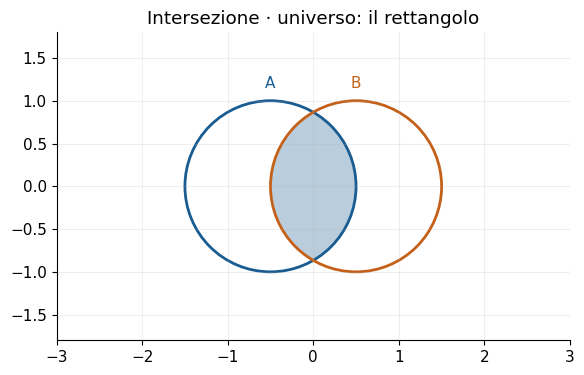

interactive(children=(Dropdown(description='operazione', options=('Intersezione', 'Unione', 'A meno B', 'Compl…

In [2]:
def insiemi(operazione='Intersezione', distanza=1.0):
    x = np.linspace(-3, 3, 450)
    y = np.linspace(-1.8, 1.8, 260)
    X, Y = np.meshgrid(x, y)
    A = (X + distanza/2)**2 + Y**2 <= 1
    B = (X - distanza/2)**2 + Y**2 <= 1
    regioni = {'Intersezione': A & B, 'Unione': A | B,
               'A meno B': A & ~B, 'Complementare di A': ~A}
    fig, ax = plt.subplots()
    ax.contourf(X, Y, regioni[operazione].astype(int), levels=[.5, 1.5],
                colors=[BLU], alpha=.3)
    for centro, etichetta, colore in [(-distanza/2, 'A', BLU), (distanza/2, 'B', ARANCIO)]:
        ax.add_patch(plt.Circle((centro, 0), 1, fill=False, color=colore, lw=2))
        ax.text(centro, 1.15, etichetta, ha='center', color=colore)
    ax.set(xlim=(-3, 3), ylim=(-1.8, 1.8), title=operazione + ' · universo: il rettangolo')
    ax.set_aspect('equal'); plt.show()

lab1 = laboratorio(insiemi,
    operazione=widgets.Dropdown(options=['Intersezione', 'Unione', 'A meno B', 'Complementare di A']),
    distanza=widgets.FloatSlider(value=1, min=0, max=2.8, step=.1, continuous_update=False))

### 1.2 Logica, quantificatori e dimostrazioni

Un **predicato** $p(x)$ dipende da una variabile libera; una **proposizione** ha un valore di verità determinato. $\forall$ significa “per ogni”; $\exists$ significa “esiste almeno un”; $\exists!$ significa “esiste esattamente un”. Il dominio delle variabili va sempre dichiarato.

$p\Rightarrow q$ è falsa soltanto quando $p$ è vera e $q$ è falsa. In un teorema $p$ è l'ipotesi e $q$ la tesi: $p$ è condizione sufficiente per $q$, e $q$ necessaria per $p$. L'equivalenza $p\iff q$ richiede entrambe le implicazioni. La **controinversa** $\neg q\Rightarrow\neg p$ equivale all'implicazione iniziale; l'inversa $q\Rightarrow p$ in generale no.

Un **controesempio** a $\forall x\in A\,[p(x)\Rightarrow q(x)]$ è un elemento che soddisfa $p$ e non $q$. Una dimostrazione diretta parte da un elemento generico che soddisfa l'ipotesi; quella per assurdo assume anche la negazione della tesi e deduce una contraddizione.

Le regole di negazione sono:
$$\neg(p\land q)\iff\neg p\lor\neg q,\quad
\neg(p\lor q)\iff\neg p\land\neg q,\quad \neg\neg p\iff p,$$
$$\neg(\forall x\,p(x))\iff\exists x\,\neg p(x),\quad
\neg(\exists x\,p(x))\iff\forall x\,\neg p(x),$$
$$\neg\bigl(\forall x\,[p(x)\Rightarrow q(x)]\bigr)
\iff\exists x\,[p(x)\land\neg q(x)].$$

**Esempi del testo.** Se $n=2k+1$, allora $n^2=2(2k^2+2k)+1$ è dispari. Ne segue per controinversa che $n^2$ pari implica $n$ pari. L'implicazione “divisibile per 4 $\Rightarrow$ divisibile per 2” equivale a $D_4\subseteq D_2$, dove $D_j=\{n\in\mathbb N:j\mid n\}$.

**Enunciato 1.1, volutamente falso (p. 10).** “Ogni numero primo è dispari”. Il controesempio è $2$, primo e pari. Non va memorizzato come teorema vero.

**Teorema 1.2 · Irrazionalità di $\sqrt2$.** Non esiste $r\in\mathbb Q$ tale che $r^2=2$.

**Dimostrazione.** Supponiamo $r=p/q$ con $q\ne0$ e $p,q$ coprimi. Da $p^2=2q^2$ segue che $p$ è pari, dunque $p=2h$. Sostituendo si ottiene $q^2=2h^2$, così anche $q$ è pari: contraddizione con la coprimalità. Il ragionamento prova l'inesistenza in $\mathbb Q$; l'esistenza della radice in $\mathbb R$ usa la completezza.

**Esempio aggiunto · L'ordine dei quantificatori conta.** $\forall x\in\mathbb R\,\exists y\in\mathbb R:y>x$ è vera (scegli $y=x+1$); $\exists y\in\mathbb R\,\forall x\in\mathbb R:y>x$ è falsa (scegli $x=y$).

In [3]:
righe = ['| p | q | p implica q | controinversa | q implica p |',
         '|---|---|---|---|---|']
for p, q in product([False, True], repeat=2):
    righe.append(f'| {p} | {q} | {(not p) or q} | {q or (not p)} | {(not q) or p} |')
display(Markdown('\n'.join(righe)))

| p | q | p implica q | controinversa | q implica p |
|---|---|---|---|---|
| False | False | True | True | True |
| False | True | True | True | False |
| True | False | False | False | True |
| True | True | True | True | True |

## 2. Sommatorie e coefficienti binomiali

### 2.1 Sommatorie

**Definizione 1.1.** $\sum_{k=1}^n a_k=a_1+\cdots+a_n$. L'indice $k$ è muto: può essere rinominato, purché coerentemente. Gli estremi invece fanno parte del significato. Per esempio $\sum_{i=1}^{10}1/i=1+1/2+\cdots+1/10$, mentre $\sum_{i=3}^n i^2=9+16+\cdots+n^2$ per $n\ge3$.

**Proposizione 1.1 · Regole di calcolo.** Per intervalli di indici interi non vuoti:
$$\sum_{k=m}^n ca_k=c\sum_{k=m}^n a_k,\qquad
\sum_{k=m}^n c=(n-m+1)c,$$
$$\sum_{k=m}^n(a_k+b_k)=\sum_{k=m}^n a_k+\sum_{k=m}^n b_k,$$
$$\sum_{k=1}^{n+r}a_k=\sum_{k=1}^n a_k+\sum_{k=n+1}^{n+r}a_k,$$
$$\sum_{k=1}^n a_k=\sum_{j=1+h}^{n+h}a_{j-h}
=\sum_{k=1}^n a_{n-k+1}=\sum_{k=0}^{n-1}a_{n-k}.$$
La dimostrazione consiste nell'espandere le somme: la traslazione cambia le etichette degli addendi, la riflessione ne inverte l'ordine. Una somma senza addendi vale $0$.

Una **progressione geometrica** ha termini $a,aq,aq^2,\ldots$, dove $q$ è la ragione. La descrizione come rapporto tra termini consecutivi richiede che il denominatore non sia nullo; la formula dei termini resta sensata anche per $q=0$.

**Proposizione 1.2.** Per $n\ge0$,
$$\sum_{k=0}^n q^k=\begin{cases}(1-q^{n+1})/(1-q),&q\ne1,\\n+1,&q=1.\end{cases}$$
**Dimostrazione.** Se $S=1+q+\cdots+q^n$, sottraendo $qS$ da $S$ rimangono $1-q^{n+1}$. Per primo termine $a$ basta moltiplicare la formula per $a$. Il termine di grado zero vale 1 anche quando $q=0$ (convenzione dei polinomi).

### 2.2 Fattoriale e permutazioni

Per $n\ge1$, $n!=1\cdot2\cdots n$; si pone $0!=1$. Vale $n!=n(n-1)!$ e, per $0\le k\le n$,
$$\frac{n!}{(n-k)!}=n(n-1)\cdots(n-k+1).$$
Per $k=0$ il prodotto vuoto è 1. Ci sono $n!$ **permutazioni** di $n$ oggetti distinti: $n$ scelte per il primo posto, $n-1$ per il secondo, e così via. Per tre oggetti: $abc,acb,bac,bca,cab,cba$. Per evitare numeri intermedi enormi, $100!/95!=100\cdot99\cdot98\cdot97\cdot96=9\,034\,502\,400$.

### 2.3 Coefficienti binomiali

Per $0\le k\le n$, $\binom nk=n!/[k!(n-k)!]$: conta i sottoinsiemi di $k$ elementi di un insieme di $n$ elementi. Vale
$$\binom n0=\binom nn=1,\qquad \binom nk=\binom n{n-k},\qquad
\binom nk=\binom{n-1}{k-1}+\binom{n-1}k\quad(1\le k\le n-1).$$
La terza identità genera il **triangolo di Tartaglia**. La formula di Newton è
$$(a+b)^n=\sum_{k=0}^n\binom nk a^k b^{n-k}.$$
La dimostrazione per induzione è nel §7 (Teorema 1.9). Ad esempio
$$(a+b)^5=a^5+5a^4b+10a^3b^2+10a^2b^3+5ab^4+b^5.$$

### Laboratorio 2 · Somme geometriche e triangolo di Tartaglia

**Prevedi:** per $q<0$ quali termini cambiano segno? Che cosa succede a $q=1$? Il laboratorio mostra somme **finite**, non dimostra la convergenza di una serie.

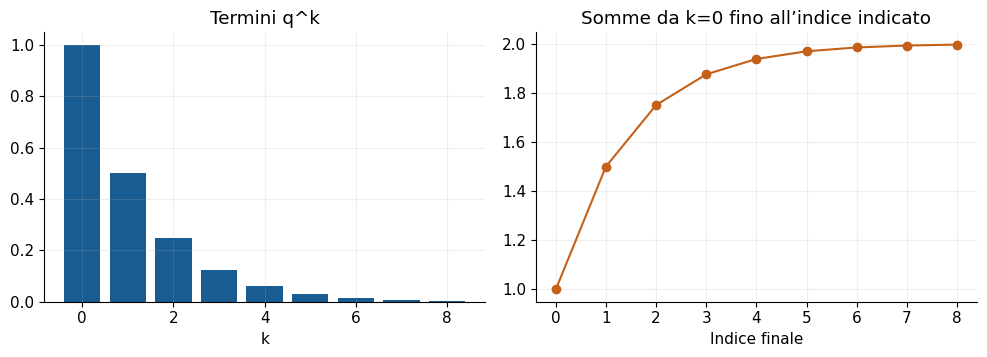

Somma di 9 addendi = 1.9960938
Riga n del triangolo: [1, 8, 28, 56, 70, 56, 28, 8, 1]


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='q', max=1.5, min=-1.5), Int…

In [4]:
def somme(q=.5, n=8):
    k = np.arange(n+1)
    termini = np.array([q**int(j) for j in k])
    fig, assi = plt.subplots(1, 2, figsize=(10, 3.7))
    assi[0].bar(k, termini, color=BLU); assi[0].set(title='Termini q^k', xlabel='k')
    assi[1].plot(k, np.cumsum(termini), 'o-', color=ARANCIO)
    assi[1].set(title='Somme da k=0 fino all’indice indicato', xlabel='Indice finale')
    plt.tight_layout(); plt.show()
    print(f'Somma di {n+1} addendi = {sum(termini):.8g}')
    print('Riga n del triangolo:', [math.comb(n, j) for j in range(n+1)])

lab2 = laboratorio(somme,
    q=widgets.FloatSlider(value=.5, min=-1.5, max=1.5, step=.1, continuous_update=False),
    n=widgets.IntSlider(value=8, min=0, max=16, continuous_update=False))

### Esercizi 1–7 · Svolgimenti (pp. 17–18)

#### Esercizio 1 · Sviluppare $(1+a)^8$ e $(2a-3b)^7$

La riga 8 è $1,8,28,56,70,56,28,8,1$, quindi
$$(1+a)^8=1+8a+28a^2+56a^3+70a^4+56a^5+28a^6+8a^7+a^8.$$
Per il secondo sviluppo il termine con $b^k$ è $\binom7k(2a)^{7-k}(-3b)^k$. Pertanto
$$(2a-3b)^7=128a^7-1344a^6b+6048a^5b^2-15120a^4b^3
+22680a^3b^4-20412a^2b^5+10206ab^6-2187b^7.$$

#### Esercizio 2 · $4\binom x4=15\binom{x-2}3$

Con la definizione fattoriale del capitolo il dominio è $x\in\mathbb N$, $x\ge5$. Espandendo e semplificando il fattore positivo $(x-2)(x-3)/6$:
$$x(x-1)=15(x-4)\iff x^2-16x+60=0\iff(x-6)(x-10)=0.$$
Le soluzioni sono **$x=6,10$**. Un'eventuale convenzione che ponga a zero i binomiali fuori dominio cambierebbe il problema e qui non viene usata.

#### Esercizio 3 · Somma dei primi $n$ interi

Posto $S=\sum_{i=1}^n i$, rifletti l'indice nella seconda copia:
$$2S=\sum_{i=1}^n[i+(n+1-i)]=n(n+1),\qquad S=\frac{n(n+1)}2.$$

#### Esercizio 4 · Somma dei dispari

$$\sum_{k=0}^{n-1}(2k+1)=2\frac{(n-1)n}{2}+n=n^2.$$
Il numero di addendi è $n$, non $n+1$.

#### Esercizio 5 · Somma dei quadrati

Somma $(k+1)^3-k^3=3k^2+3k+1$ per $k=0,\ldots,n$. Il membro sinistro telescopico vale $(n+1)^3$, dunque
$$3\sum_{k=1}^n k^2=(n+1)^3-3\frac{n(n+1)}2-(n+1).$$
Raccogliendo $(n+1)$ e semplificando si ottiene $\sum_{k=1}^n k^2=n(n+1)(2n+1)/6$.

#### Esercizio 6 · Somma telescopica

$$\sum_{k=1}^{100}\left(\frac1k-\frac1{k+1}\right)
=(1-\tfrac12)+(\tfrac12-\tfrac13)+\cdots+(\tfrac1{100}-\tfrac1{101})=\frac{100}{101}.$$

#### Esercizio 7 · Due somme geometriche

Poiché $(-1)^k2^{3k+1}/3^k=2(-8/3)^k$,
$$\sum_{k=0}^{30}(-1)^k\frac{2^{3k+1}}{3^k}
=\frac6{11}\left[1-\left(-\frac83\right)^{31}\right].$$
Nella seconda poni $j=k-2$, che varia da $0$ a $98$:
$$\sum_{k=2}^{100}3^{2-k}=\sum_{j=0}^{98}(1/3)^j
=\frac32(1-3^{-99}).$$

## 3. Campi ordinati

**Definizione 1.2 · Campo e campo ordinato.** Un campo è un insieme $K$ con due operazioni interne $+$ e $\cdot$, con $0\ne1$, tale che:

| Somma | Prodotto |
|---|---|
| $a+b=b+a$ | $ab=ba$ |
| $(a+b)+c=a+(b+c)$ | $(ab)c=a(bc)$ |
| $a+0=a$ | $a1=a$ |
| ogni $a$ ha opposto $-a$ | ogni $a\ne0$ ha reciproco $a^{-1}$ |

Vale inoltre $a(b+c)=ab+ac$. Sottrazione e divisione sono $a-b=a+(-b)$ e $a/b=ab^{-1}$, quest'ultima solo per $b\ne0$.

Una **relazione d'ordine** è riflessiva, antisimmetrica e transitiva. È **totale** se ogni coppia è confrontabile. Un campo ordinato ha un ordine totale compatibile con le operazioni:
$$a\le b\Rightarrow a+c\le b+c,\qquad
a\le b,\ c>0\Rightarrow ac\le bc.$$
Da qui, moltiplicando per un numero negativo, il verso si inverte. $\mathbb Q$ e $\mathbb R$ sono campi ordinati; $\mathbb Z$ non è un campo perché $2$ non ha reciproco intero.

**Esempio di ordine non totale.** Su $\mathcal P(X)$ l'inclusione è riflessiva, antisimmetrica e transitiva. Se $X$ contiene due elementi distinti $a,b$, né $\{a\}\subseteq\{b\}$ né $\{b\}\subseteq\{a\}$. Per insiemi $X$ con al più un elemento, invece, l'ordine è totale.

**Esempio svolto aggiunto.** $-2x\le6$ equivale a $x\ge-3$, perché si divide per $-2$. Da $x^2\le x$ non si può dividere direttamente per $x$: il segno non è noto e $x=0$ è ammissibile. Si fattorizza $x(x-1)\le0$, ottenendo $x\in[0,1]$.

## 4. Reali, estremi, valore assoluto e intervalli

### 4.1 Perché i razionali non bastano

La diagonale del quadrato unitario ha lunghezza $d$ con $d^2=2$. Il Teorema 1.2 impedisce che $d$ sia razionale. Essere un campo ordinato non basta a descrivere tutte le lunghezze della retta.

### 4.2 Maggioranti, minoranti, massimi ed estremi

Sia $E\subseteq X$, dove $X$ è totalmente ordinato. Un **maggiorante** $M\in X$ soddisfa $x\le M$ per ogni $x\in E$; un **minorante** $m\in X$ soddisfa $m\le x$ per ogni $x\in E$. L'insieme è **limitato superiormente/inferiormente** se esiste un maggiorante/minorante; è **limitato** se valgono entrambe le proprietà.

Il **massimo** è un maggiorante che appartiene a $E$; il **minimo** un minorante che appartiene a $E$. Possono non esistere, ma se esistono sono unici per antisimmetria.

**Definizione 1.3.** $\sup E$ è il minimo dei maggioranti; $\inf E$ è il massimo dei minoranti, quando questi elementi esistono in $X$. Gli estremi dipendono anche dall'insieme ambiente. Se esiste il massimo, coincide con il supremo; viceversa un supremo è massimo esattamente quando appartiene a $E$.

**Caratterizzazione utile, aggiunta.** Per $\varnothing\ne E\subseteq\mathbb R$ e $s\in\mathbb R$,
$$s=\sup E\iff
\begin{cases}x\le s&\forall x\in E,\\
\forall\varepsilon>0\ \exists x\in E:\ s-\varepsilon<x.&\end{cases}$$
Infatti la seconda condizione dice che nessun numero minore di $s$ è un maggiorante. Analogamente $t=\inf E$ se $t$ è minorante e per ogni $\varepsilon>0$ esiste $x\in E$ con $x<t+\varepsilon$.

**Definizione 1.4 e assioma di completezza (R4).** $\mathbb R$ è un campo ordinato completo: ogni suo sottoinsieme **non vuoto** e **limitato superiormente** ha estremo superiore reale. Non si richiede che $\mathbb R$ stesso abbia supremo. La proprietà dell'infimo segue applicando R4 a $-E$: $\inf E=-\sup(-E)$.

Una **partizione** in due parti è una coppia $A,B$ di insiemi non vuoti, disgiunti, con $A\cup B=\mathbb R$. È una **sezione di Dedekind** se $a<b$ per ogni $a\in A,b\in B$. La formulazione equivalente della completezza dice che esiste un unico **separatore** $s$ con $a\le s\le b$ per tutte queste coppie, e $s=\sup A=\inf B$.

**Perché R4 implica il separatore.** $A$ è non vuoto e ogni $b\in B$ è suo maggiorante: poni $s=\sup A$. Allora $a\le s\le b$. Se ci fossero due separatori $s<t$, il punto medio, che deve stare in $A$ oppure in $B$, contraddirebbe una delle due proprietà. **Viceversa**, per $E$ non vuoto e superiormente limitato, separa i numeri che non sono maggioranti da quelli che lo sono; il separatore è il minimo dei maggioranti. Se fosse minore di un elemento di $E$, un numero intermedio non sarebbe maggiorante ma starebbe sopra il separatore, assurdo.

### Esempi 4.1 del libro, completati

Nella tabella ‐nessuno‑ significa nessun estremo **reale finito**; $+\infty,-\infty$ sono eventuali convenzioni nei reali estesi, non elementi di $\mathbb R$.

| Insieme &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Infimo in $\mathbb R$ | Minimo | Supremo in $\mathbb R$ | Massimo |
|---|---|---|---|---|
| $\mathbb N$ | $0$ | $0$ | nessuno | nessuno |
| $2\mathbb Z$ | nessuno | nessuno | nessuno | nessuno |
| $\{1/n:n\ge1\}$ | $0$ | nessuno | $1$ | $1$ |
| $\{(n-1)/(n+1):n\in\mathbb N\}$ | $-1$ | $-1$ | $1$ | nessuno |
| $\{x\in\mathbb R:x^3\ge27\}$ | $3$ | $3$ | nessuno | nessuno |
| $\{q\in\mathbb Q:q\ge0,q^2<2\}$ | $0$ | $0$ | $\sqrt2$ | nessuno |

**Giustificazioni.** $\mathbb N$ e $2\mathbb Z$ contengono numeri arbitrariamente grandi; il secondo anche arbitrariamente piccoli. Per $1/n$, scegli $n>1/\varepsilon$ per trovare un elemento sotto $\varepsilon$; nessun elemento    zero. Per $(n-1)/(n+1)=1-2/(n+1)$, tutti i termini sono minori di 1, e basta $n+1>2/\varepsilon$ per superare $1-\varepsilon$. La quinta riga    $[3,+\infty)$ perch   il cubo    strettamente crescente. Nell'ultima riga i razionali approssimano $\sqrt2$ dal basso: il supremo esiste in $\mathbb R$, **non in $\mathbb Q$**.

Le scelte di interi arbitrariamente grandi usano la **propriet   archimedea**, conseguenza di R4: se $\mathbb N$ avesse un supremo $s$, esisterebbe $n>s-1$, e allora $n+1>s$. La densit   di $\mathbb Q$ segue scegliendo $n$ con $1/n<b-a$ e un intero $m$ con $na<m\le na+1$: $a<m/n<b$.

### Laboratorio 3 · Il supremo non è il massimo del campione

Mostriamo solo i primi $N$ elementi di $E=\{1-2/(n+1):n\in\mathbb N\}$. Il campione finito ha massimo, l'insieme infinito no. **Compito:** trova sulla carta un indice con $1-\varepsilon<x_n<1$, poi controlla se compare nel campione.

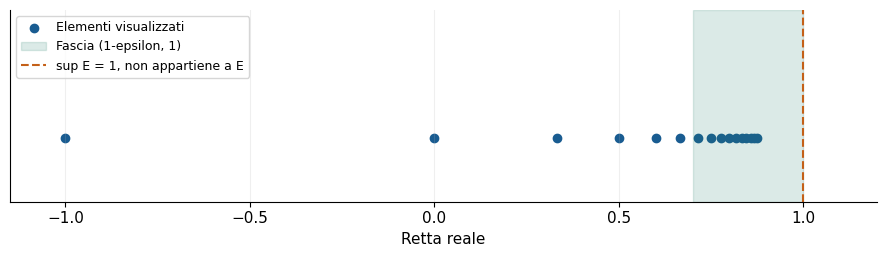

Un indice sufficiente è n=7: x_n=0.750000.
Massimo del solo campione: 0.875000; supremo dell’intero E: 1.


interactive(children=(IntSlider(value=15, continuous_update=False, description='N', max=150, min=1), FloatSlid…

In [5]:
def estremo(N=15, epsilon=.3):
    n = np.arange(N+1)
    valori = 1-2/(n+1)
    fig, ax = plt.subplots(figsize=(9, 2.7))
    ax.scatter(valori, np.zeros_like(valori), color=BLU, label='Elementi visualizzati')
    ax.axvspan(1-epsilon, 1, color=VERDE, alpha=.16, label='Fascia (1-epsilon, 1)')
    ax.axvline(1, color=ARANCIO, ls='--', label='sup E = 1, non appartiene a E')
    ax.set(xlim=(-1.15, 1.2), ylim=(-.3, .6), yticks=[], xlabel='Retta reale')
    ax.legend(loc='upper left', fontsize=9); plt.tight_layout(); plt.show()
    testimone = math.floor(2/epsilon) + 1
    print(f'Un indice sufficiente è n={testimone}: x_n={1-2/(testimone+1):.6f}.')
    print(f'Massimo del solo campione: {valori[-1]:.6f}; supremo dell’intero E: 1.')

lab3 = laboratorio(estremo,
    N=widgets.IntSlider(value=15, min=1, max=150, continuous_update=False),
    epsilon=widgets.FloatSlider(value=.3, min=.02, max=1, step=.02, continuous_update=False))

### 4.3 Valore assoluto e distanza

**Definizione.** $|a|=a$ per $a\ge0$ e $|a|=-a$ per $a<0$. Per $r\ge0$, $|x|\le r\iff-r\le x\le r$. Inoltre $|ab|=|a||b|$, $|-a|=|a|$ e $|a-b|$ è la distanza tra $a$ e $b$.

**Disuguaglianza triangolare e conseguenze.**
$$|x+y|\le|x|+|y|,\qquad
|a-b|\le|a-c|+|b-c|,$$
$$\bigl||a|-|b|\bigr|\le|a-b|,\qquad
\left|\sum_{k=1}^n a_k\right|\le\sum_{k=1}^n|a_k|.$$
**Dimostrazione.** Somma $-|x|\le x\le|x|$ e $-|y|\le y\le|y|$. Per la forma inversa usa $|a|\le|a-b|+|b|$ e scambia $a,b$. La versione con $n$ addendi segue per induzione. L'esempio $x=2,y=-2$ mostra che l'uguaglianza non vale sempre.

### 4.4 Intervalli

Per $a<b$, $[a,b]=\{x:a\le x\le b\}$ è chiuso, $(a,b)=\{x:a<x<b\}$ è aperto; $[a,b)$ e $(a,b]$ includono un solo estremo. Si considerano anche semirette, ad esempio $(-\infty,b)$ e $[a,+\infty)$, e $\mathbb R=(-\infty,+\infty)$. L'infinito non è un estremo incluso.

**Caratterizzazione.** Un sottoinsieme $I\subseteq\mathbb R$ è un intervallo se contiene ogni punto compreso fra due suoi punti: $x_1<x_2<x_3$, $x_1,x_3\in I\Rightarrow x_2\in I$. Si ammettono anche i casi degeneri vuoto e singoletto. **Idea della prova inversa:** poni $a=\inf I,b=\sup I$, eventualmente infiniti; ogni punto strettamente fra $a,b$ è fra due punti di $I$, quindi appartiene a $I$. L'appartenenza dei due estremi determina il tipo di parentesi.

**Esempi svolti.** $|x-2|<3$ equivale a $-1<x<5$. Il prodotto $[0,1]\times[1,2]$ è un rettangolo; scambiando i fattori si ottiene $[1,2]\times[0,1]$, diverso dal primo. $[0,1]^2$ è il quadrato unitario.

## 5. Radicali, potenze, logaritmi e approssimazioni

### 5.1 Radici aritmetiche

**Teorema 1.3.** Per $y>0$ e intero $n\ge1$ esiste un unico $x>0$ con $x^n=y$. Si scrive $x=\sqrt[n]y=y^{1/n}$. Si estende ponendo $\sqrt[n]0=0$. In particolare $\sqrt{a^2}=|a|$, non sempre $a$.

**Giustificazione.** L'unicità discende da $v^n-u^n=(v-u)(v^{n-1}+v^{n-2}u+\cdots+u^{n-1})>0$ per $v>u\ge0$. L'esistenza segue dalla completezza; il testo ne rinvia la dimostrazione con le funzioni continue al capitolo 3. Anticipandola: $t\mapsto t^n$ è continua, vale 0 in 0 e supera $y$ per $t$ abbastanza grande, quindi il teorema dei valori intermedi fornisce la radice. Questa parte usa risultati successivi, non il grafico.

**Esempio del testo · Costruire $\sqrt2$.** $1^2<2<2^2$, $1{,}4^2<2<1{,}5^2$, $1{,}41^2<2<1{,}42^2$, e così via. Le approssimazioni inferiori hanno supremo $\sqrt2$; quelle superiori infimo $\sqrt2$. Un intervallo razionale certificato è più informativo di una cifra fornita senza controllo.

### 5.2 Potenze reali

Per $a>0$, $m\in\mathbb Z,n\ge1$, $a^{m/n}=\sqrt[n]{a^m}$; il valore non dipende dalla rappresentazione della frazione. Per $a>1$ e $b\in\mathbb R$ si può definire $a^b=\sup\{a^q:q\in\mathbb Q,q<b\}$; per $0<a<1$ si pone $a^b=(1/a)^{-b}$ e per $a=1$ si pone $1^b=1$.

Per basi positive e esponenti reali valgono
$$a^0=1,\quad a^c>0,\quad a^{c+d}=a^ca^d,\quad (ab)^c=a^cb^c,\quad(a^c)^d=a^{cd}.$$
Per $a>1$ la potenza cresce strettamente con l'esponente; per $0<a<1$ decresce. Per $a=1$ è costante. Se $c>0$ e $0<a\le b$, allora $a^c\le b^c$; se $c<0$ il verso si inverte. In particolare $0<a\le1,c>0\Rightarrow a^c\le1$.

**Basi negative.** Per $a<0$ e $m/n$ ridotta ai minimi termini con $n>0$, la potenza reale è definita tramite la radice reale se $n$ è dispari. Per denominatore pari non è definita nel campo reale. Le identità delle potenze richiedono cautela fuori dalle basi positive. Esempi: $(-2)^{3/5}=-\sqrt[5]8$, $(-2)^{2/5}=\sqrt[5]4$; $(-2)^{3/4}$ non è reale. L'espressione $0^0$ non è qui definita come potenza reale generale; compare solo la convenzione per termini costanti di polinomi.

### 5.3 Logaritmi

**Teorema 1.4 e definizione.** Se $a>0$, $a\ne1$ e $y>0$, esiste un unico $x\in\mathbb R$ con $a^x=y$. Si chiama $\log_a y$. Quindi $a^{\log_a y}=y$ e $\log_a(a^x)=x$. Se $a=1$, l'equazione ha tutte le soluzioni per $y=1$ e nessuna altrimenti; se $y\le0$, non ha soluzioni per nessuna base positiva.

L'unicità usa la monotonia stretta. L'esistenza può essere dimostrata con continuità e comportamento agli estremi dell'esponenziale, sviluppati più avanti nel corso. Per $x,y>0$, $a,b>0$, $a,b\ne1$, $\alpha\in\mathbb R$:
$$\log_a(xy)=\log_a x+\log_a y,\quad
\log_a(x/y)=\log_a x-\log_a y,\quad
\log_a(x^\alpha)=\alpha\log_a x,$$
$$\log_a x=\frac1{\log_x a}\ (x\ne1),\qquad
\log_a x=-\log_{1/a}x,\qquad
\log_b x=\frac{\log_a x}{\log_a b}.$$
**Dimostrazione tipo:** scrivi $x=a^u,y=a^v$. Allora $xy=a^{u+v}$ e applica la definizione di logaritmo. Le altre identità seguono dalle corrispondenti identità delle potenze.

**Esempio aggiunto.** $\log_2(x-1)+\log_2(x+1)=3$ richiede $x>1$. Unendo i logaritmi: $x^2-1=8$, quindi $x=3$; la radice $-3$ è esclusa dal dominio.

### 5.4 Approssimazioni

Scrivere un irrazionale significa specificarlo esattamente tramite una definizione (ad esempio l'unica radice positiva di $x^2=2$), oppure approssimarlo a precisione richiesta. Non tutti i reali sono calcolabili da un algoritmo: la specificazione algoritmica vale per gli esempi computabili che stiamo usando.

Con $d$ cifre dopo la virgola, il troncamento di un numero non negativo ha errore minore di $10^{-d}$; l'arrotondamento al più vicino ha errore al più $\tfrac12 10^{-d}$. Per la convenzione scolastica sui positivi: $2{,}4138\mapsto2{,}41$, $2{,}4152\mapsto2{,}42$. Nei casi esattamente a metà bisogna precisare la convenzione: Python può arrotondare al pari. I numeri a virgola mobile non sono l'intero campo reale e nemmeno tutti i razionali.

### Laboratorio 4 · Un intervallo certificato per $\sqrt2$

Usiamo interi e frazioni esatte: nessun confronto fra quadrati dipende dagli errori dei `float`. **Compito:** spiega perché l'ampiezza dell'intervallo certifica l'errore dell'estremo inferiore.

707/500 < sqrt(2) < 283/200
Intervallo decimale: (1.414, 1.415)
Ampiezza esatta: 1/1000. Quadrati confrontati con aritmetica razionale.


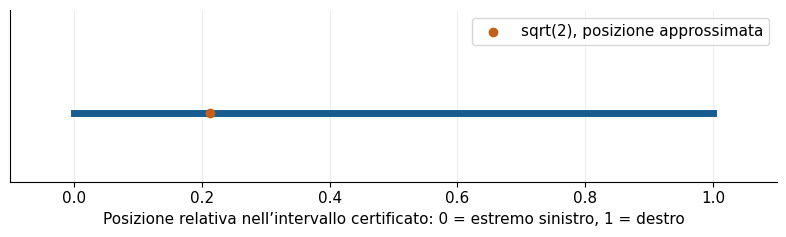

interactive(children=(IntSlider(value=3, continuous_update=False, description='cifre', max=8), Output()), _dom…

Esempio di virgola mobile: 0.30000000000000004 == 0.3 ? False
Con frazioni esatte: True


In [6]:
def radice_due(cifre=3):
    scala = 10**cifre
    p = math.isqrt(2*scala*scala)
    inferiore = Fraction(p, scala)
    superiore = Fraction(p+1, scala)
    assert inferiore**2 < 2 < superiore**2
    print(f'{inferiore} < sqrt(2) < {superiore}')
    print(f'Intervallo decimale: ({float(inferiore):.{cifre}f}, {float(superiore):.{cifre}f})')
    print(f'Ampiezza esatta: 1/{scala}. Quadrati confrontati con aritmetica razionale.')
    fig, ax = plt.subplots(figsize=(8, 2.5))
    # Coordinate relative: evitano di nascondere intervalli piccoli su una retta enorme.
    posizione = (math.sqrt(2)-float(inferiore))*scala
    ax.plot([0, 1], [0, 0], lw=5, color=BLU)
    ax.scatter([posizione], [0], color=ARANCIO, zorder=5, label='sqrt(2), posizione approssimata')
    ax.set(xlim=(-.1, 1.1), ylim=(-.2, .3), yticks=[],
           xlabel='Posizione relativa nell’intervallo certificato: 0 = estremo sinistro, 1 = destro')
    ax.legend(); plt.tight_layout(); plt.show()

lab4 = laboratorio(radice_due,
    cifre=widgets.IntSlider(value=3, min=0, max=8, continuous_update=False))

print('Esempio di virgola mobile:', 0.1 + 0.2, '== 0.3 ?', 0.1 + 0.2 == 0.3)
print('Con frazioni esatte:', Fraction(1,10) + Fraction(2,10) == Fraction(3,10))

## 6. Insiemi infiniti

### Cardinalità e numerabilità

**Definizione 1.5.** Due insiemi hanno la stessa **cardinalità** (o potenza) se esiste una corrispondenza biunivoca fra essi: ogni elemento del primo è associato a uno e un solo elemento del secondo e viceversa. Una funzione è **iniettiva** se non identifica elementi distinti, **suriettiva** se raggiunge ogni elemento del codominio, **biiettiva** se ha entrambe le proprietà.

**Definizione 1.6.** Un insieme è **numerabile** se è equipotente a $\mathbb N$. Qui “numerabile” significa infinito numerabile; “al più numerabile” comprende anche gli insiemi finiti.

**Esempio.** La lista $0,1,-1,2,-2,\ldots$ enumera $\mathbb Z$. Esplicitamente $f(0)=0$, $f(2n-1)=n$, $f(2n)=-n$ per $n\ge1$ dà una biiezione $\mathbb N\to\mathbb Z$. Anche i pari naturali sono equipotenti ai naturali tramite $n\mapsto2n$: un'inclusione propria non implica cardinalità strettamente minore.

**Teorema 1.5.** $\mathbb Q$ è numerabile.

**Dimostrazione.** Elenca le coppie di interi positivi $(p,q)$ per somme $p+q=2,3,4,\ldots$, e in ogni diagonale elenca $p/q$ scartando le frazioni non ridotte. Ogni razionale positivo compare esattamente una volta dopo un numero finito di passi. Inserisci poi zero e alterna ogni razionale positivo con il suo opposto.

**Teorema 1.6.** $\mathbb R$ non è numerabile.

**Dimostrazione diagonale.** Supponi di elencare tutti i numeri di $[0,1)$, con sviluppi decimali scelti non terminanti in infiniti 9. Se $a_{nn}$ è la cifra diagonale del numero numero $n$, costruisci $b_n=5$ quando $a_{nn}\le4$, $b_n=4$ altrimenti. Il numero $0{,}b_1b_2\ldots$ appartiene a $[0,1)$ e differisce dal numero numero $n$ nella cifra $n$. Poiché usa solo 4 e 5, non ha l'ambiguità dei decimali terminanti; non è in elenco: contraddizione.

La cardinalità di $\mathbb R$ si chiama **potenza del continuo**. Ogni intervallo non degenere ha questa cardinalità. Per esempio $t\mapsto\tan(\pi(t-1/2))$ è una biiezione $(0,1)\to\mathbb R$. Anche $[0,1]$, il quadrato e gli spazi $\mathbb R^n$ con $n\ge1$ hanno la stessa cardinalità, benché abbiano dimensioni diverse. I complementi spiegano il caso del quadrato; un punto o un intervallo vuoto sono eccezioni alla frase “ogni intervallo”.

**Teorema 1.7 · Cantor.** Per ogni insieme $A$, $|\mathcal P(A)|>|A|$.

**Dimostrazione.** L'iniezione $a\mapsto\{a\}$ dà $|A|\le|\mathcal P(A)|$. Se una funzione $f:A\to\mathcal P(A)$ fosse suriettiva, il sottoinsieme $D=\{a\in A:a\notin f(a)\}$ sarebbe $f(d)$ per un certo $d$. Ma $d\in D\iff d\notin D$, impossibile. Non esiste quindi alcuna biiezione. Il ragionamento produce gerarchie di cardinalità sempre maggiori.

### Laboratorio 5 · Enumerare i razionali e osservare la diagonale

Il primo pannello produce un **prefisso finito** dell'elenco dei razionali positivi. Il secondo visualizza il meccanismo diagonale su cifre simulate: nessuna matrice finita dimostra da sola la non numerabilità.

Prefisso di Q positivi: 1, 1/2, 2, 1/3, 3, 1/4, 2/3, 3/2, 4, 1/5, 5, 1/6, 2/5, 3/4, 4/3, 5/2, 6


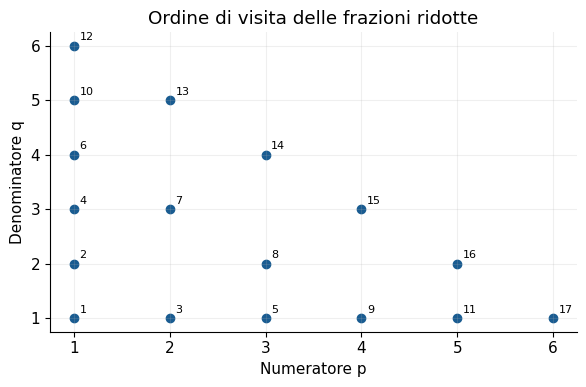

r1: 0.076448...
r2: 0.062059...
r3: 0.777751...
r4: 0.845319...
r5: 0.764854...
r6: 0.420580...
Numero diagonale, prime cifre: 0.544545...


interactive(children=(IntSlider(value=6, continuous_update=False, description='diagonali', max=10, min=2), Out…

In [7]:
def cardinalita(diagonali=6):
    coppie = [(p, s-p) for s in range(2, diagonali+2)
              for p in range(1, s) if math.gcd(p, s-p) == 1]
    print('Prefisso di Q positivi:', ', '.join(str(Fraction(p,q)) for p,q in coppie))
    fig, ax = plt.subplots(figsize=(6, 4))
    for posizione, (p, q) in enumerate(coppie, 1):
        ax.scatter(p, q, color=BLU)
        ax.annotate(str(posizione), (p, q), xytext=(4, 4), textcoords='offset points', fontsize=8)
    ax.set(xlabel='Numeratore p', ylabel='Denominatore q', title='Ordine di visita delle frazioni ridotte')
    plt.tight_layout(); plt.show()
    rng = np.random.default_rng(42)
    cifre = rng.integers(0, 10, (diagonali, diagonali))
    nuova = np.where(np.diag(cifre) <= 4, 5, 4)
    for j, riga in enumerate(cifre):
        print(f'r{j+1}: 0.' + ''.join(map(str, riga)) + '...')
    print('Numero diagonale, prime cifre: 0.' + ''.join(map(str, nuova)) + '...')
    assert np.all(nuova != np.diag(cifre))

lab5 = laboratorio(cardinalita,
    diagonali=widgets.IntSlider(value=6, min=2, max=10, continuous_update=False))

## 7. Il principio di induzione

Per dimostrare $P(n)$ per ogni intero $n\ge n_0$ occorrono:

1. **Base:** dimostrare $P(n_0)$.
2. **Passo:** per un generico $n\ge n_0$, assumere $P(n)$ e dedurre $P(n+1)$.

Si assume la proprietà per **quel generico indice** per provare un'implicazione, non si assume la conclusione universale. In forma insiemistica: se $S\subseteq\mathbb N$, $0\in S$ e $n\in S\Rightarrow n+1\in S$, allora $S=\mathbb N$. È un assioma dei naturali.

**Teorema 1.8 · Bernoulli.** Per $x\ge-1$ e intero $n\ge1$,
$$(1+x)^n\ge1+nx.$$
Per $n=0$ l'identità è 1=1 con la convenzione del polinomio costante.

**Dimostrazione.** La base $n=1$ è un'uguaglianza. Supposto vero per $n$, moltiplica per $1+x\ge0$:
$$(1+x)^{n+1}\ge(1+nx)(1+x)=1+(n+1)x+nx^2\ge1+(n+1)x.$$
L'ipotesi $x\ge-1$ giustifica il verso della prima disuguaglianza. Per $n\ge2$ l'uguaglianza si ha solo per $x=0$; per $x=-1$ la verifica è diretta.

**Teorema 1.9 · Binomio di Newton.** Per $n\ge0$ e $a,b\in\mathbb R$,
$$(a+b)^n=\sum_{k=0}^n\binom nk a^k b^{n-k}.$$
**Dimostrazione.** Per $n=0$ i due membri sono il polinomio costante 1. Moltiplica la formula per $a+b$. Per $1\le k\le n$ il coefficiente di $a^k b^{n+1-k}$ è $\binom n{k-1}+\binom nk=\binom{n+1}k$; i termini estremi sono $b^{n+1}$ e $a^{n+1}$. Questo dà la formula al passo successivo. L'identità dei coefficienti si dimostra algebricamente nell'esercizio 13, quindi non c'è circolarità.

### Esercizi 8–13 · Svolgimenti per induzione (pp. 34–35)

#### Esercizio 8 · $\sum_{k=1}^n k=n(n+1)/2$

Base $n=1$: $1=1$. Al passo successivo:
$$\sum_{k=1}^{n+1}k=\frac{n(n+1)}2+(n+1)=\frac{(n+1)(n+2)}2.$$

#### Esercizio 9 · Somma geometrica

Per $q\ne1$, la base $n=0$ è $1=(1-q)/(1-q)$. Poi
$$\sum_{k=0}^{n+1}q^k=\frac{1-q^{n+1}}{1-q}+q^{n+1}
=\frac{1-q^{n+2}}{1-q}.$$
Per $q=1$ la formula separata è il numero degli addendi.

#### Esercizio 10 · Somma dei pari

La formula è $\sum_{k=1}^n2k=n(n+1)$. Base: $2=1\cdot2$. Passo:
$$n(n+1)+2(n+1)=(n+1)(n+2).$$

#### Esercizio 11 · Somma dei dispari

La formula è $\sum_{k=0}^{n-1}(2k+1)=n^2$. Base: $1=1$. Il nuovo termine è $2n+1$, dunque $n^2+(2n+1)=(n+1)^2$.

#### Esercizio 12 · Cardinalità dell'insieme delle parti

Per $n=0$, $\mathcal P(\varnothing)=\{\varnothing\}$ ha $1=2^0$ elementi. Aggiungendo un elemento $a$ a un insieme di $n$ elementi, ogni sottoinsieme o non contiene $a$ o si ottiene aggiungendo $a$ a uno dei vecchi sottoinsiemi. Le due classi sono disgiunte e hanno ciascuna $2^n$ elementi: in totale $2^{n+1}$.

#### Esercizio 13 · Identità di Pascal

Per $1\le k\le n$:
$$\binom n{k-1}+\binom nk
=\frac{n!k+n!(n+1-k)}{k!(n+1-k)!}
=\frac{(n+1)!}{k!(n+1-k)!}=\binom{n+1}k.$$
È una dimostrazione algebrica diretta; non serve l'induzione.

### Laboratorio 6 · Il margine nella disuguaglianza di Bernoulli

**Prevedi:** dove la differenza è zero? Prova $n=1$ e $n=2$. Il grafico è una verifica visiva su un intervallo; la dimostrazione è il passo induttivo sopra.

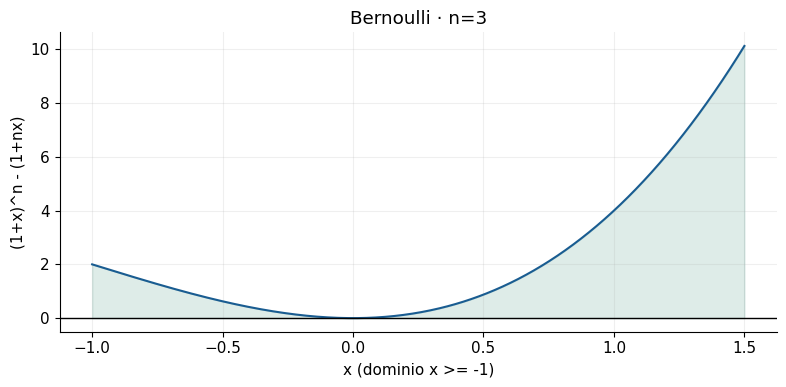

interactive(children=(IntSlider(value=3, continuous_update=False, description='n', max=10, min=1), Output()), …

In [8]:
def bernoulli(n=3):
    x = np.linspace(-1, 1.5, 500)
    differenza = (1+x)**n - (1+n*x)
    fig, ax = plt.subplots()
    ax.plot(x, differenza, color=BLU)
    ax.axhline(0, color='black', lw=1)
    ax.fill_between(x, 0, differenza, color=VERDE, alpha=.15)
    ax.set(xlabel='x (dominio x >= -1)', ylabel='(1+x)^n - (1+nx)', title=f'Bernoulli · n={n}')
    plt.tight_layout(); plt.show()

lab6 = laboratorio(bernoulli,
    n=widgets.IntSlider(value=3, min=1, max=10, continuous_update=False))

## 8. Numeri complessi

### 8.1 Definizione e struttura di campo

Su $\mathbb R^2$ definiamo
$$(a,b)+(c,d)=(a+c,b+d),\qquad(a,b)(c,d)=(ac-bd,ad+bc).$$
Con queste operazioni otteniamo il campo $\mathbb C$: gli elementi neutri sono $(0,0)$ e $(1,0)$, l'opposto di $(a,b)$ è $(-a,-b)$ e, per $(a,b)\ne(0,0)$, il reciproco è
$$\left(\frac a{a^2+b^2},\frac{-b}{a^2+b^2}\right).$$
Commutatività, associatività e distributività si verificano espandendo i due membri. Identifichiamo $(a,0)$ con $a\in\mathbb R$ e poniamo $i=(0,1)$: $i^2=-1$. La **forma algebrica** è $z=a+ib$, con **parte reale** $\operatorname{Re}z=a$ e **parte immaginaria** $\operatorname{Im}z=b$, che è un numero reale, non $ib$.

Il **piano di Gauss** rappresenta $a+ib$ con il punto $(a,b)$. I numeri $ib$ sono immaginari puri. La somma segue la regola del parallelogramma; l'opposto è il punto simmetrico rispetto all'origine.

**Impossibilità di ordinare $\mathbb C$ come campo.** In ogni campo ordinato il quadrato di un elemento non nullo è positivo: se $u<0$, allora $-u>0$ e $u^2=(-u)^2>0$. Ma $i^2=-1<0$, assurdo. Si possono definire ordini sull'insieme $\mathbb C$, ma non compatibili con tutte le proprietà di campo ordinato.

### 8.2 Coniugato e modulo

Il **coniugato** di $z=a+ib$ è $\bar z=a-ib$. Il **modulo** è $|z|=\sqrt{a^2+b^2}$. Valgono
$$z+\bar z=2\operatorname{Re}z,\quad z-\bar z=2i\operatorname{Im}z,\quad z\bar z=|z|^2,$$
$$\overline{z+w}=\bar z+\bar w,\quad\overline{zw}=\bar z\bar w,\quad\overline{\bar z}=z.$$
Inoltre $|z|\ge0$, $|z|=0\iff z=0$, $|\bar z|=|z|$ e
$$|\operatorname{Re}z|\le|z|,\quad |\operatorname{Im}z|\le|z|,\quad
|z|\le|\operatorname{Re}z|+|\operatorname{Im}z|,$$
$$|z+w|\le|z|+|w|,\qquad \bigl||z|-|w|\bigr|\le|z+w|.$$
Sostituendo $w$ con $-w$ si ottiene anche $\bigl||z|-|w|\bigr|\le|z-w|$. La distanza fra i punti $z,w$ è $|z-w|$.

**Dimostrazione della triangolare.** Poiché $\operatorname{Re}(z\bar w)\le|z\bar w|=|z||w|$,
$$|z+w|^2=|z|^2+|w|^2+2\operatorname{Re}(z\bar w)\le(|z|+|w|)^2.$$
Qui $|zw|=|z||w|$ si verifica direttamente da $(zw)\overline{zw}=z\bar z\,w\bar w$. La disuguaglianza inversa segue applicando la triangolare a $z=(z+w)-w$ e poi scambiando $z,w$.

Per $w=c+id\ne0$:
$$\frac{a+ib}{c+id}=\frac{(a+ib)(c-id)}{c^2+d^2}
=\frac{ac+bd}{c^2+d^2}+i\frac{bc-ad}{c^2+d^2}.$$

### Esempio 8.1 · Un'equazione con coniugato (pp. 39–40)

Risolvere $z^2+i\operatorname{Im}z+2\bar z=0$. Con $z=x+iy$:
$$x^2-y^2+2x=0,\qquad y(2x-1)=0.$$
Se $y=0$, $x(x+2)=0$, quindi $z=0,-2$. Se $x=1/2$, $y^2=5/4$, quindi
$$z=\frac12\pm i\frac{\sqrt5}{2}.$$
Le quattro soluzioni sono ammissibili. L'equazione coinvolge $\bar z$ e non è un polinomio nel solo $z$: il suo grado apparente non limita il numero delle soluzioni a due.

### 8.3 Forma trigonometrica e formule di De Moivre

Per $z\ne0$, poni $\rho=|z|>0$ e scegli un **argomento** $\theta$ con $a=\rho\cos\theta$, $b=\rho\sin\theta$. Allora
$$z=\rho(\cos\theta+i\sin\theta).$$
Gli argomenti differiscono per multipli di $2\pi$. La scelta in $(-\pi,\pi]$ è l'**argomento principale** $\operatorname{Arg}z$. Per $z=0$ l'argomento non è definito. Non basta $\arctan(b/a)$ senza controllare il quadrante; in Python `atan2(b,a)` gestisce i quadranti.

**Esempi.** $-i$ ha argomenti $-\pi/2+2k\pi$; $\sqrt3+i=2(\cos(\pi/6)+i\sin(\pi/6))$. I reali positivi hanno argomento principale 0, i reali negativi $\pi$.

Scrivendo $\mathrm{cis}(\theta)=\cos\theta+i\sin\theta$ solo come abbreviazione:
$$z_1z_2=\rho_1\rho_2\mathrm{cis}(\theta_1+\theta_2),\qquad
\frac{z_1}{z_2}=\frac{\rho_1}{\rho_2}\mathrm{cis}(\theta_1-\theta_2),$$
$$z_1\cdots z_n=(\rho_1\cdots\rho_n)\mathrm{cis}(\theta_1+\cdots+\theta_n),\qquad
z^n=\rho^n\mathrm{cis}(n\theta).$$
Il quoziente richiede $z_2\ne0$. La formula per potenze vale per interi positivi; per interi negativi richiede $z\ne0$. Gli argomenti si sommano **modulo $2\pi$**, non necessariamente come argomenti principali. Le formule seguono dalle identità di addizione di seno e coseno; le potenze per induzione.

Moltiplicare per $\rho\mathrm{cis}(\theta)$ significa ruotare di $\theta$ e dilatare di fattore $\rho$. Per $i$: rotazione di $\pi/2$; per $-1$: di $\pi$; per $1+i$: rotazione di $\pi/4$ e dilatazione di $\sqrt2$.

### Esempi 8.3–8.4 · Potenze ed equazioni (pp. 42–43)

**$(1+i)^7$.** $1+i=\sqrt2\mathrm{cis}(\pi/4)$, dunque
$$(1+i)^7=8\sqrt2\mathrm{cis}(7\pi/4)=8-8i.$$

**$z^3=|z|$.** Prima conserva la soluzione $z=0$. Per $z\ne0$, scrivi $z=\rho\mathrm{cis}(\theta)$: $\rho^3=\rho$ e $3\theta\equiv0\pmod{2\pi}$. Quindi $\rho=1$ e
$$z\in\left\{0,1,-\frac12+i\frac{\sqrt3}2,-\frac12-i\frac{\sqrt3}2\right\}.$$
Separare prima lo zero evita di attribuirgli un argomento o perderlo dividendo per il modulo.

### Laboratorio 7 · Il prodotto è una rotazione e una dilatazione

Il punto iniziale è $z=1+i/2$. **Compito:** imposta $\rho=1,\theta=\pi/2$ e prevedi le coordinate finali prima di leggere il risultato. Prova poi un angolo negativo.

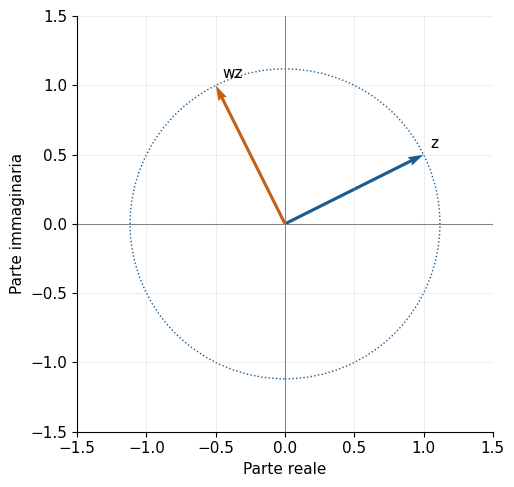

w = 0.0000+1.0000j, wz = -0.5000+1.0000j; |wz| = 1.1180


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='rho', max=3.0, min=0.2), Fl…

In [9]:
def prodotto_complesso(rho=1.0, angolo_pi=.5):
    z = 1+.5j
    theta = angolo_pi*np.pi
    w = rho*complex(np.cos(theta), np.sin(theta))
    risultato = z*w
    fig, ax = plt.subplots(figsize=(6, 5))
    for punto, nome, colore in [(z, 'z', BLU), (risultato, 'wz', ARANCIO)]:
        ax.quiver(0, 0, punto.real, punto.imag, angles='xy', scale_units='xy', scale=1, color=colore)
        ax.annotate(nome, (punto.real, punto.imag), xytext=(5, 5), textcoords='offset points')
    ax.add_patch(plt.Circle((0, 0), abs(z), fill=False, color=BLU, ls=':'))
    limite = max(1.5, abs(risultato)*1.3)
    ax.set(xlim=(-limite, limite), ylim=(-limite, limite), xlabel='Parte reale', ylabel='Parte immaginaria')
    ax.axhline(0, color='gray', lw=.7); ax.axvline(0, color='gray', lw=.7)
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()
    print(f'w = {w:.4f}, wz = {risultato:.4f}; |wz| = {abs(risultato):.4f}')

lab7 = laboratorio(prodotto_complesso,
    rho=widgets.FloatSlider(value=1, min=.2, max=3, step=.1, continuous_update=False),
    angolo_pi=widgets.FloatSlider(value=.5, min=-2, max=2, step=1/12,
                                 description='angolo / pi', continuous_update=False))

### 8.4 Radici complesse, equazioni di secondo grado e algebra

**Definizione.** Una radice $n$-esima complessa di $w$ è un $z$ tale che $z^n=w$.

**Teorema 1.10.** Per $w=r\mathrm{cis}(\varphi)\ne0$ e intero $n\ge1$ esistono esattamente $n$ radici distinte:
$$z_k=r^{1/n}\mathrm{cis}\left(\frac{\varphi+2k\pi}{n}\right),\qquad k=0,\ldots,n-1.$$
**Dimostrazione.** De Moivre verifica che $z_k^n=w$. Viceversa, ogni radice deve avere modulo $r^{1/n}$ e angolo $(\varphi+2h\pi)/n$ con $h\in\mathbb Z$. La divisione euclidea $h=k+mn$ riconduce a uno dei $n$ valori; sono distinti perché le differenze di angoli per $0\le k<n$ non sono multipli non nulli di $2\pi$. Per $w=0$ l'unica radice distinta è 0.

Per $n\ge3$ le radici sono i vertici di un poligono regolare; per $n=2$ due punti opposti; per $n=1$ un solo punto. Non confondere $\sqrt4=2$ (radice aritmetica) con le soluzioni $\{-2,2\}$ di $z^2=4$.

**Esempi del testo (pp. 44–45).**

- $z^3=-1$: $\{\tfrac12+i\tfrac{\sqrt3}2,-1,\tfrac12-i\tfrac{\sqrt3}2\}$.
- $z^6=i$: $z_k=\mathrm{cis}(\pi/12+k\pi/3)$, $k=0,\ldots,5$.
- $z^5=1+i$: $z_k=2^{1/10}\mathrm{cis}(\pi/20+2k\pi/5)$, $k=0,\ldots,4$.

**Equazioni quadratiche.** Per $a\ne0$, $az^2+bz+c=0$ si risolve scegliendo una delle radici $s$ di $s^2=b^2-4ac$ e ponendo $z=(-b\pm s)/(2a)$. Se il discriminante è zero, si ha una radice doppia. Ad esempio
$$z^2+2iz-\sqrt3 i=0\quad\Rightarrow\quad
z=-i\pm\sqrt2\mathrm{cis}(\pi/3)
=\pm\frac{\sqrt2}{2}+i\left(-1\pm\frac{\sqrt6}{2}\right),$$
con segni coordinati. Si è usato $-1+i\sqrt3=2\mathrm{cis}(2\pi/3)$.

**Teorema 1.11 · Teorema fondamentale dell'algebra.** Un polinomio complesso $P(z)=a_nz^n+\cdots+a_0$, di grado $n\ge1$ ($a_n\ne0$), ha esattamente $n$ radici in $\mathbb C$ contate con molteplicità. Una radice $z_0$ ha **molteplicità** $k$ se $P(z)=(z-z_0)^kQ(z)$ con $Q(z_0)\ne0$. Il teorema è enunciato senza dimostrazione nel capitolo; anche qui non se ne propone una prova, che richiede strumenti ulteriori. Non si applica direttamente alle equazioni con $\bar z$ o $|z|$.

### Laboratorio 8 · Tutte le radici, non solo quella principale

**Prevedi:** ruotando $w$ di un angolo $\delta$, di quanto ruota il poligono delle radici? Che cosa cambia aumentando $n$? Il laboratorio impone $r>0$, come nel Teorema 1.10.

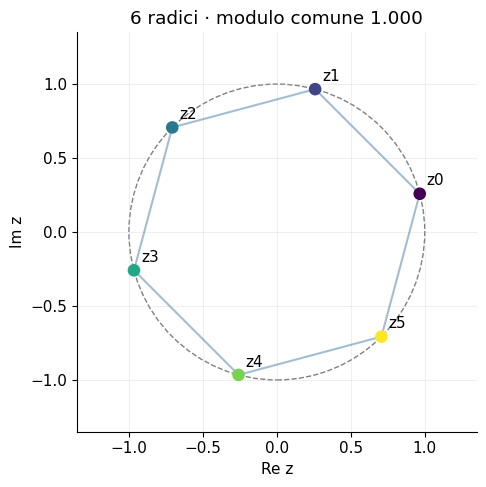

Massimo residuo numerico |z_k^n - w|: 1.27e-15


interactive(children=(IntSlider(value=6, continuous_update=False, description='n', max=12, min=1), FloatSlider…

In [10]:
def radici(n=6, r=1.0, phi_pi=.5):
    phi = phi_pi*np.pi
    angoli = (phi+2*np.pi*np.arange(n))/n
    z = r**(1/n)*(np.cos(angoli)+1j*np.sin(angoli))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.add_patch(plt.Circle((0, 0), r**(1/n), fill=False, color='gray', ls='--'))
    if n > 1:
        chiuso = np.r_[z, z[0]]
        ax.plot(chiuso.real, chiuso.imag, color=BLU, alpha=.4)
    ax.scatter(z.real, z.imag, c=np.arange(n), cmap='viridis', s=65, zorder=3)
    for k, punto in enumerate(z):
        ax.annotate(f'z{k}', (punto.real, punto.imag), xytext=(5, 6), textcoords='offset points')
    limite = r**(1/n)*1.35
    ax.set(xlim=(-limite, limite), ylim=(-limite, limite), xlabel='Re z', ylabel='Im z',
           title=f'{n} radici · modulo comune {r**(1/n):.3f}')
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()
    w = r*complex(np.cos(phi), np.sin(phi))
    print('Massimo residuo numerico |z_k^n - w|:', f'{np.max(np.abs(z**n-w)):.2e}')

lab8 = laboratorio(radici,
    n=widgets.IntSlider(value=6, min=1, max=12, continuous_update=False),
    r=widgets.FloatSlider(value=1, min=.1, max=4, step=.1, continuous_update=False),
    phi_pi=widgets.FloatSlider(value=.5, min=-1, max=1, step=1/12,
                              description='arg w / pi', continuous_update=False))

### Esercizi 14–25 · Calcolo e geometria complessa (p. 46)

#### Esercizio 14 · Tre espressioni in forma algebrica

Razionalizza il denominatore moltiplicando per il suo coniugato:
$$\frac{(2+i)(1-i)}{3-2i}=\frac{3-i}{3-2i}
=\frac{(3-i)(3+2i)}{13}=\frac{11}{13}+\frac3{13}i.$$
Poiché $i(3+2i)^2=-12+5i$,
$$\frac1{i(3+2i)^2}=\frac{-12-5i}{169}.$$
Infine $(\sqrt3+i\sqrt2)^3=-3\sqrt3+7i\sqrt2$, quindi
$$\frac{(\sqrt3+i\sqrt2)^3}{\sqrt2-i\sqrt3}
=\frac{(-3\sqrt3+7i\sqrt2)(\sqrt2+i\sqrt3)}5=-2\sqrt6+i.$$

#### Esercizio 15 · Modulo e argomento

| Numero &nbsp;&nbsp;&nbsp;&nbsp;| Modulo | Argomento principale |
|---|---|---|
| $-3i$ | $3$ | $-\pi/2$ |
| $-5$ | $5$ | $\pi$ |
| $-\sqrt3+i$ | $2$ | $5\pi/6$ |

Si calcola $\sqrt{a^2+b^2}$ e si individua il quadrante. Tutti gli altri argomenti si ottengono aggiungendo $2k\pi$, $k\in\mathbb Z$.

#### Esercizio 16 · Moduli e argomenti di quozienti

Dividi i moduli e sottrai gli argomenti:

| Numero &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;| Modulo | Argomento principale e calcolo |
|---|---|---|
| $(1+i\sqrt3)/(1-i)$ | $\sqrt2$ | $\pi/3-(-\pi/4)=7\pi/12$ |
| $(1+i)/(1-i)$ | $1$ | $\pi/4-(-\pi/4)=\pi/2$ |
| $(1+i)/(\sqrt3+i)$ | $1/\sqrt2$ | $\pi/4-\pi/6=\pi/12$ |

#### Esercizio 17 · Luoghi geometrici

Scrivi $z=x+iy$.

**i)** $|z|=|z+i|\iff x^2+y^2=x^2+(y+1)^2\iff y=-1/2$: l'asse del segmento fra $0$ e $-i$.

**ii)** $\operatorname{Re}(z^2)>2\iff x^2-y^2>2$. È l'unione delle due regioni $x>\sqrt{y^2+2}$ e $x<-\sqrt{y^2+2}$; l'iperbole di bordo è esclusa.

**iii)** $\operatorname{Im}(1/z)=-1$ richiede $z\ne0$. Poiché $1/z=(x-iy)/(x^2+y^2)$,
$$-y/(x^2+y^2)=-1\iff x^2+(y-1/2)^2=1/4.$$
È la circonferenza di centro $(0,1/2)$ e raggio $1/2$, **privata dell'origine**.

#### Esercizio 18 · Stime sul modulo

Da $x^2\le x^2+y^2$ segue $x\le|x|\le|z|$; analogamente $y\le|z|$. Inoltre
$$(|x|+|y|)^2=x^2+y^2+2|xy|\ge|z|^2,$$
e prendendo radici non negative si ottiene $|z|\le|x|+|y|$.

#### Esercizio 19 · Potenze e una formula parametrica

$$\frac{1-i\sqrt3}{1+i}=\frac{1-\sqrt3}{2}-i\frac{1+\sqrt3}{2}.$$
Per il secondo, $(1-i)/(1+i)=-i$, dunque il cubo vale $i$. Usando De Moivre:
$$(1+i)^{20}=2^{10}\mathrm{cis}(5\pi)=-1024,$$
$$(1-i)^{11}=2^{11/2}\mathrm{cis}(-11\pi/4)=-32-32i.$$
Per ogni intero $n\ge0$,
$$(1+i\sqrt3)^n-(1-i\sqrt3)^n
=2^n[\mathrm{cis}(n\pi/3)-\mathrm{cis}(-n\pi/3)]
=i\,2^{n+1}\sin(n\pi/3).$$
La parte reale è zero; la parte immaginaria è il numero reale indicato.

#### Esercizio 20 · Radici seste di $-1$

$-1=\mathrm{cis}(\pi)$, quindi gli angoli sono $\pi/6+k\pi/3$, $k=0,\ldots,5$:
$$\left\{\frac{\sqrt3}2+\frac i2,\ i,\ -\frac{\sqrt3}2+\frac i2,
-\frac{\sqrt3}2-\frac i2,\ -i,\ \frac{\sqrt3}2-\frac i2\right\}.$$
Si dispongono su un esagono regolare unitario. Nel laboratorio 8 imposta $n=6,r=1,\mathrm{arg}(w)/\pi=1$.

#### Esercizio 21 · Due equazioni

**a)** Poni $u=z-2$. Le radici cubiche di $-i=\mathrm{cis}(-\pi/2)$ hanno angoli $-\pi/6,\pi/2,7\pi/6$. Pertanto
$$z\in\left\{2+\frac{\sqrt3}2-\frac i2,\ 2+i,\ 2-\frac{\sqrt3}2-\frac i2\right\}.$$
**b)** $z^2-(4+i)z+4+2i=(z-2)(z-(2+i))$, dunque $z=2,2+i$.

#### Esercizio 22 · Formula per $\cos5\theta$

Prendi la parte reale di $(\cos\theta+i\sin\theta)^5$:
$$\cos5\theta=\cos^5\theta-10\cos^3\theta\sin^2\theta+5\cos\theta\sin^4\theta.$$
I termini con potenze dispari di $i$ sono immaginari; quelli con $i^2,i^4$ hanno segni $-,+$.

#### Esercizio 23 · Linearizzare $\sin^4\theta$

Due applicazioni della formula di duplicazione danno
$$\sin^4\theta=\left(\frac{1-\cos2\theta}{2}\right)^2
=\frac38-\frac12\cos2\theta+\frac18\cos4\theta.$$
La costante può essere vista come $\tfrac38\cos(0\theta)$.

#### Esercizio 24 · Tre insiemi di radici

**a) $z^3=i-1$.** Modulo $\sqrt2$, argomento $3\pi/4$; ponendo $R=2^{1/6}$:
$$z_k=R\mathrm{cis}(\pi/4+2k\pi/3),\quad k=0,1,2.$$
In forma algebrica, usando le formule di addizione per $15^\circ$ e $75^\circ$:
$$\frac R{\sqrt2}(1+i),\qquad
\frac R4[-(\sqrt6+\sqrt2)+i(\sqrt6-\sqrt2)],\qquad
\frac R4[(\sqrt6-\sqrt2)-i(\sqrt6+\sqrt2)].$$

**b) $z^2=-1+i\sqrt3$.** Modulo del radicando 2 e argomento $2\pi/3$:
$$z=\pm\sqrt2\mathrm{cis}(\pi/3)=\pm\left(\frac{\sqrt2}{2}+i\frac{\sqrt6}{2}\right).$$

**c) $z^4=-2-2\sqrt3 i$.** Modulo 4, argomento $-2\pi/3$:
$$z_k=\sqrt2\mathrm{cis}(-\pi/6+k\pi/2),\quad k=0,1,2,3.$$
Esplicitamente:
$$\frac{\sqrt6}{2}-i\frac{\sqrt2}{2},\quad
\frac{\sqrt2}{2}+i\frac{\sqrt6}{2},\quad
-\frac{\sqrt6}{2}+i\frac{\sqrt2}{2},\quad
-\frac{\sqrt2}{2}-i\frac{\sqrt6}{2}.$$

#### Esercizio 25 · Un settore anulare e la sua rotazione

$A=\{z:1<|z|<2,\ \pi/6<\arg z<\pi/3\}$ è il settore aperto di una corona circolare fra raggi 1 e 2 e angoli $30^\circ,60^\circ$. Tutti i bordi sono esclusi. $B=\{iz:z\in A\}$ si ottiene ruotando di $90^\circ$:
$$B=\{w:1<|w|<2,\ 2\pi/3<\arg w<5\pi/6\}.$$

### Laboratorio 9 · I luoghi degli esercizi 17 e 25

Il punto vuoto evidenzia l'origine esclusa dalla circonferenza. La griglia campiona le regioni; le formule esatte ne determinano i bordi. **Compito:** deduci prima il disegno dalla formula e controlla poi se coincide.

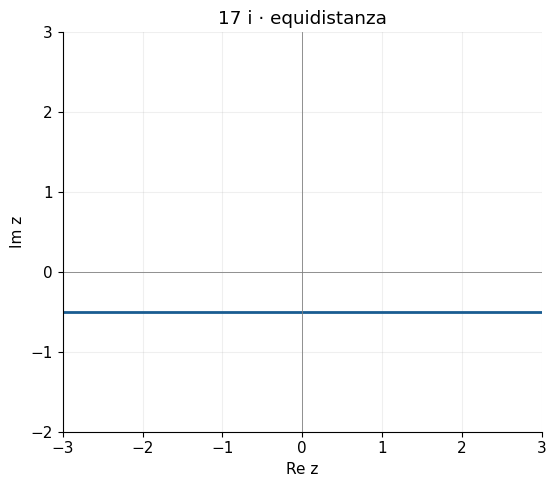

interactive(children=(Dropdown(description='scelta', options=('17 i · equidistanza', '17 ii · iperbole', '17 i…

In [11]:
def luoghi(scelta='17 i · equidistanza'):
    fig, ax = plt.subplots(figsize=(6, 5))
    t = np.linspace(0, 2*np.pi, 600)
    if scelta.startswith('17 i ·'):
        ax.axhline(-.5, color=BLU, lw=2)
    elif scelta.startswith('17 ii ·'):
        y = np.linspace(-3, 3, 500)
        bordo = np.sqrt(y*y+2)
        ax.fill_betweenx(y, bordo, 4, color=BLU, alpha=.25)
        ax.fill_betweenx(y, -4, -bordo, color=BLU, alpha=.25)
        ax.plot(bordo, y, '--', color=BLU); ax.plot(-bordo, y, '--', color=BLU)
    elif scelta.startswith('17 iii ·'):
        ax.plot(.5*np.cos(t), .5+.5*np.sin(t), color=BLU, lw=2)
        ax.scatter([0], [0], facecolors='white', edgecolors=ARANCIO, s=100, zorder=5)
        ax.annotate('origine esclusa', (0, 0), xytext=(.3, -.5), arrowprops={'arrowstyle':'->'})
    else:
        for shift, nome, colore in [(0, 'A', BLU), (np.pi/2, 'B = iA', ARANCIO)]:
            ang = np.linspace(np.pi/6+shift, np.pi/3+shift, 120)
            bordo = np.r_[np.exp(1j*ang), 2*np.exp(1j*ang[::-1]), np.exp(1j*ang[:1])]
            ax.fill(bordo.real, bordo.imag, color=colore, alpha=.2, label=nome)
            ax.plot(bordo.real, bordo.imag, '--', color=colore)
        ax.legend()
    ax.axhline(0, color='gray', lw=.6); ax.axvline(0, color='gray', lw=.6)
    ax.set(xlim=(-3, 3), ylim=(-2, 3), xlabel='Re z', ylabel='Im z', title=scelta)
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()

lab9 = laboratorio(luoghi,
    scelta=widgets.Dropdown(options=['17 i · equidistanza', '17 ii · iperbole',
                                     '17 iii · circonferenza bucata', '25 · settori aperti']))

### Esercizi 26–35 · Tutte le soluzioni (p. 47)

#### Esercizio 26 · $z^2+2z+3=0$

Completa il quadrato: $(z+1)^2=-2$. Quindi **$z=-1\pm i\sqrt2$**.

#### Esercizio 27 · $z+3i+(\operatorname{Re}z)(i+(\operatorname{Im}z)^2)=0$

Con $z=x+iy$, le due parti sono $x(1+y^2)=0$ e $y+3+x=0$. Poiché $1+y^2>0$, $x=0$, quindi $y=-3$. L'unica soluzione è **$z=-3i$**.

#### Esercizio 28 · $z^2+2iz-3=0$

$(z+i)^2=2$. Le soluzioni sono **$z=-i\pm\sqrt2$**.

#### Esercizio 29 · $iz^3=\bar z$

$z=0$ è soluzione. Per $z=\rho\mathrm{cis}(\theta)\ne0$, confrontando moduli $\rho^3=\rho$, quindi $\rho=1$; confrontando argomenti $3\theta+\pi/2\equiv-\theta\pmod{2\pi}$. Pertanto
$$\boxed{z=0\quad\text{oppure}\quad z=\mathrm{cis}(-\pi/8+k\pi/2),\quad k=0,1,2,3.}$$

#### Esercizio 30 · $iz^2+(1+i)z+1=0$

Si fattorizza $i(z+1)(z-i)=0$; dunque **$z=-1,i$**. Il controllo dei coefficienti dà $i(1-i)=1+i$ e $i(-i)=1$.

#### Esercizio 31 · $z^6+2z^3-3=0$

Poni $u=z^3$. $u^2+2u-3=(u-1)(u+3)=0$. Sono quindi le tre radici cubiche di 1 e le tre di $-3$:
$$z=\mathrm{cis}(2k\pi/3)\quad\text{oppure}\quad
z=\sqrt[3]3\,\mathrm{cis}(\pi/3+2k\pi/3),\quad k=0,1,2.$$
Le due terne sono disgiunte perché hanno moduli diversi.

#### Esercizio 32 · $z^2+\bar z=0$

Con $z=x+iy$:
$$x^2-y^2+x=0,\qquad y(2x-1)=0.$$
Se $y=0$, $x=0,-1$; se $x=1/2$, $y^2=3/4$. Le soluzioni sono
$$\boxed{0,\ -1,\ \frac12+i\frac{\sqrt3}{2},\ \frac12-i\frac{\sqrt3}{2}.}$$

#### Esercizio 33 · $(\bar z)^4=|z|$

Conserva $z=0$. Per $z\ne0$, $\rho^4=\rho\Rightarrow\rho=1$ e $-4\theta\equiv0\pmod{2\pi}$. Quindi **$z\in\{0,1,i,-1,-i\}$**.

#### Esercizio 34 · $i\operatorname{Re}z+z^2=|z|^2+1$

La parte reale impone $x^2-y^2=x^2+y^2+1$, cioè $-2y^2=1$, impossibile per $y\in\mathbb R$. **Nessuna soluzione**, indipendentemente dalla parte immaginaria.

#### Esercizio 35 · $2|z|^2=z^3$

$z=0$ è soluzione. Per $z\ne0$, $2\rho^2=\rho^3\Rightarrow\rho=2$ e $3\theta\equiv0\pmod{2\pi}$. Dunque
$$\boxed{z\in\{0,2,-1+i\sqrt3,-1-i\sqrt3\}.}$$

## 9. Complementi · Svolgimenti (p. 47)

### Complemento 1 · Unione e intersezione infinite

Per $A_n\subseteq X$, $n\ge1$,
$$\bigcup_{n=1}^{\infty}A_n=\{x\in X:\exists n\ge1,\ x\in A_n\},$$
$$\bigcap_{n=1}^{\infty}A_n=\{x\in X:\forall n\ge1,\ x\in A_n\}.$$
L'esistenza traduce “almeno uno”, l'universalità “tutti”. Ad esempio per $A_n=(-1/n,1/n)$, l'unione è $(-1,1)$ e l'intersezione $\{0\}$: se $x\ne0$, scegli $n>1/|x|$ per escluderlo da almeno un $A_n$.

### Complemento 2 · $\log_2 3$ è irrazionale

Supponi $\log_2 3=p/q$ con $p,q$ interi positivi (il logaritmo è positivo). Allora $2^p=3^q$. Il primo numero è pari, il secondo dispari: impossibile.

### Complemento 3 · Proprietà dei coefficienti binomiali

I valori agli estremi seguono da $0!=1$: $\binom n0=\binom nn=1$. La simmetria si legge nel denominatore $k!(n-k)!$. Per Pascal, con $1\le k\le n-1$:
$$\binom{n-1}{k-1}+\binom{n-1}k
=\frac{(n-1)![k+(n-k)]}{k!(n-k)!}
=\frac{n!}{k!(n-k)!}=\binom nk.$$
Questa è la versione con indici traslati dell'esercizio 13.

### Complemento 4 · Bernoulli dal binomio

Per $x\ge0$ e $n\ge2$,
$$(1+x)^n=1+nx+\sum_{k=2}^n\binom nk x^k\ge1+nx,$$
perché ogni addendo residuo è non negativo. Per $n=0,1$ l'identità è immediata. Questa prova non copre $-1\le x<0$, dove i termini possono alternare segno; lì si usa la dimostrazione induttiva.

### Uno strumento aggiunto per i complementi 5 e 6

Il semplice intreccio di decimali, senza convenzioni, può fallire: $0{,}5000\ldots=0{,}4999\ldots$. Per dare prove complete usiamo il **teorema di Cantor–Schröder–Bernstein**: se esistono iniezioni $f:A\to B$ e $g:B\to A$, esiste una biiezione fra $A$ e $B$.

**Dimostrazione e costruzione.** Poni $A_0=A\setminus g(B)$, $A_{n+1}=g(f(A_n))$ e $D=\bigcup_{n\ge0}A_n$. Definisci $h(a)=f(a)$ per $a\in D$ e $h(a)=g^{-1}(a)$ per $a\notin D$. Il secondo ramo è definito perché $a\notin A_0$; l'inversa sul sottoinsieme $g(B)$ è unica per iniettività. Ogni ramo è iniettivo e le loro immagini sono disgiunte: se $f(d)=g^{-1}(a)$ con $d\in D$, allora $a=g(f(d))\in D$, contraddizione. Per la suriettività, dato $b\in B$, se $g(b)\notin D$ usa il secondo ramo; se $g(b)\in D$, non è in $A_0$, quindi è in qualche $A_{n+1}$ e per iniettività di $g$ si ha $b=f(a)$ per un $a\in A_n\subseteq D$. Dunque $h$ è biiettiva.

### Complemento 5 · Segmento e quadrato hanno la stessa cardinalità

Un'iniezione $[0,1]\to[0,1]^2$ è $t\mapsto(t,0)$. Costruiamo l'altra in modo da evitare ambiguità. Per $(x,y)\in[0,1]^2$ considera gli sviluppi binari **canonici** di $x/2$ e $y/2$, scegliendo quelli non definitivamente uguali a 1:
$$x/2=\sum_{n\ge1}a_n2^{-n},\qquad y/2=\sum_{n\ge1}b_n2^{-n},\qquad a_n,b_n\in\{0,1\}.$$
La divisione per 2 assicura che anche gli estremi abbiano una rappresentazione di questo tipo. Associa la coppia al numero
$$F(x,y)=\sum_{n\ge1}\frac{a_n}{3^{2n-1}}+\frac{b_n}{3^{2n}}\in[0,1].$$
Le cifre ternarie sono solo 0 e 1; al primo posto $m$ in cui due sequenze differiscono, il contributo $3^{-m}$ è maggiore della massima coda compensatrice $\sum_{j>m}3^{-j}=\tfrac12 3^{-m}$. Quindi la codifica è iniettiva e si possono recuperare entrambe le sequenze. Le due iniezioni e il teorema appena dimostrato danno la biiezione richiesta. La sola codifica $F$ non è dichiarata suriettiva su tutto l'intervallo.

### Complemento 6 · $\mathcal P(\mathbb N)$ e $[0,1]$

Per ogni sottoinsieme $S\subseteq\mathbb N$ poni
$$F(S)=\sum_{n=0}^{\infty}\frac{2\mathbf1_S(n)}{3^{n+1}}\in[0,1],$$
dove $\mathbf1_S(n)=1$ se $n\in S$, 0 altrimenti. È iniettiva: se la prima differenza è all'indice $m$, il termine diverso ha grandezza $2/3^{m+1}$ e la coda totale è al più $1/3^{m+1}$, insufficiente a cancellarlo.

Viceversa, per $x\in[0,1]$ prendi lo sviluppo binario canonico $x/2=\sum_{n\ge1}a_n2^{-n}$ e poni $G(x)=\{n-1:a_n=1\}$. È un'iniezione in $\mathcal P(\mathbb N)$, perché dalle cifre si ricostruisce $x$. Cantor–Schröder–Bernstein conclude. La mappa ingenua $S\mapsto\sum\mathbf1_S(n)2^{-n-1}$ non sarebbe iniettiva a causa delle doppie rappresentazioni binarie.

### Complemento 7 · Analisi del paradosso diagonale

Supponi una suriezione $f:A\to\mathcal P(A)$ e poni $D=\{a\in A:a\notin f(a)\}$. Attenzione ai tipi: **$f(a)$ è un sottoinsieme di $A$**, non necessariamente un elemento di $A$. Per suriettività esiste $d\in A$ con $f(d)=D$. Allora
$$d\in D\iff d\notin f(d)\iff d\notin D.$$
Se $d$ appartiene a $D$, non vi appartiene; se non vi appartiene, vi appartiene. L'ipotesi di suriettività è impossibile. Con $a\mapsto\{a\}$ si ottiene la disuguaglianza stretta di cardinalità del Teorema 1.7. Il ragionamento vale anche per $A=\varnothing$: in tal caso non può esserci una suriezione su $\{\varnothing\}$.

## 10. Autoverifica

Prima di guardare le risposte, risolvi questi quesiti su carta.

1. Nega $\forall x\in\mathbb R\,\exists y\in\mathbb R:y>x$.
2. Trova supremo, infimo, massimo e minimo di $(0,1]\cap\mathbb Q$.
3. Perché $\sqrt{x^2}=x$ è falsa come identità su tutti i reali?
4. Qual è l'errore nella “dimostrazione” di $P(n)$ che controlla solo $n=1,2,3$?
5. Trova tutte le soluzioni di $z^4=16$.
6. Se $A\subsetneq B$, deve valere $|A|<|B|$?

### Risposte ragionate

1. $\exists x\in\mathbb R\,\forall y\in\mathbb R:y\le x$. Si scambiano entrambi i quantificatori e si nega $>$.
2. $\sup=\max=1$, $\inf=0$; il minimo non esiste perché 0 è escluso e per ogni razionale positivo $q$ anche $q/2$ appartiene all'insieme.
3. Per $x=-2$ il primo membro è 2, il secondo $-2$. La formula corretta è $|x|$.
4. Manca il passo per un indice generico; tre casi non coprono un insieme infinito.
5. $\{2,2i,-2,-2i\}$, dai moduli 2 e dagli angoli $k\pi/2$.
6. No: $2\mathbb N\subsetneq\mathbb N$, ma $n\mapsto2n$ è una biiezione.

### Verifiche computazionali esatte

La cella seguente verifica identità e sostituzioni con aritmetica simbolica. È un controllo degli svolgimenti, non sostituisce gli argomenti che garantiscono di avere trovato **tutte** le soluzioni.

In [12]:
a, b, z = sp.symbols('a b z')
x, y, theta = sp.symbols('x y theta', real=True)
I = sp.I
def uguali(sinistra, destra):
    assert sp.simplify(sp.expand_complex(sinistra-destra)) == 0

sviluppo = (128*a**7-1344*a**6*b+6048*a**5*b**2-15120*a**4*b**3
            +22680*a**3*b**4-20412*a**2*b**5+10206*a*b**6-2187*b**7)
assert sp.expand((2*a-3*b)**7-sviluppo) == 0
assert [n for n in range(5, 51) if 4*math.comb(n,4)==15*math.comb(n-2,3)] == [6,10]
assert sum((Fraction(1,k)-Fraction(1,k+1) for k in range(1,101)), Fraction(0)) == Fraction(100,101)
assert sum((2*Fraction(-8,3)**k for k in range(31)), Fraction(0)) == Fraction(6,11)*(1-Fraction(-8,3)**31)
assert sum((Fraction(1,3)**k for k in range(99)), Fraction(0)) == Fraction(3,2)*(1-Fraction(1,3)**99)

es14 = [((2+I)*(1-I)/(3-2*I), (11+3*I)/13),
        (1/(I*(3+2*I)**2), (-12-5*I)/169),
        ((sp.sqrt(3)+I*sp.sqrt(2))**3/(sp.sqrt(2)-I*sp.sqrt(3)), -2*sp.sqrt(6)+I)]
for espressione, risultato in es14:
    uguali(espressione, risultato)
uguali((1+I)**7, 8-8*I)
uguali((1+I)**20, -1024)
uguali((1-I)**11, -32-32*I)

equazioni = [
    (z**2+2*z+3, [-1+I*sp.sqrt(2), -1-I*sp.sqrt(2)]),
    (z**2+2*I*z-3, [-I+sp.sqrt(2), -I-sp.sqrt(2)]),
    (I*z**2+(1+I)*z+1, [-1, I]),
    (z**2-(4+I)*z+4+2*I, [2,2+I])]
for polinomio, soluzioni in equazioni:
    for soluzione in soluzioni:
        uguali(polinomio.subs(z, soluzione), 0)

for soluzione in [0,-2,sp.Rational(1,2)+I*sp.sqrt(5)/2,sp.Rational(1,2)-I*sp.sqrt(5)/2]:
    uguali(soluzione**2 + I*sp.im(soluzione) + 2*sp.conjugate(soluzione), 0)
for soluzione in [0,-1,sp.Rational(1,2)+I*sp.sqrt(3)/2,sp.Rational(1,2)-I*sp.sqrt(3)/2]:
    uguali(soluzione**2+sp.conjugate(soluzione), 0)
for soluzione in [0,1,I,-1,-I]:
    uguali(sp.conjugate(soluzione)**4-sp.Abs(soluzione), 0)
for soluzione in [0,2,-1+I*sp.sqrt(3),-1-I*sp.sqrt(3)]:
    uguali(2*sp.Abs(soluzione)**2-soluzione**3, 0)

assert sp.trigsimp(sp.expand_trig(sp.cos(5*theta)) -
    (sp.cos(theta)**5-10*sp.cos(theta)**3*sp.sin(theta)**2+5*sp.cos(theta)*sp.sin(theta)**4)) == 0
assert sp.trigsimp(sp.sin(theta)**4-(sp.Rational(3,8)-sp.cos(2*theta)/2+sp.cos(4*theta)/8)) == 0
print('Controlli esatti superati: sviluppi, somme, espressioni complesse, equazioni e identità trigonometriche.')

Controlli esatti superati: sviluppi, somme, espressioni complesse, equazioni e identità trigonometriche.


### Riferimenti e corrispondenza con il testo

| Contenuti del libro | Posizione nel quaderno |
|---|---|
| Definizione 1.1, Proposizioni 1.1–1.2 | §2 |
| Definizione 1.2 | §3 |
| Definizioni 1.3–1.4 | §4 |
| Definizioni 1.5–1.6 | §6 |
| Enunciato falso 1.1 e Teorema 1.2 | §1.2 |
| Teoremi 1.3–1.4 | §5 |
| Teoremi 1.5–1.7 | §6 |
| Teoremi 1.8–1.9 | §7 |
| Teoremi 1.10–1.11 | §8.4 |
| Esercizi 1–7, 8–13, 14–25, 26–35 | rispettivamente §§2, 7, 8, 8 |
| Complementi 1–7 | §9 |

